Thông tin chung về IRIS DATASET

Tổng số mẫu: 150

Số lớp: 3 loài hoa Iris

setosa

versicolor

virginica

Số đặc trưng: 4 (liên tục, đơn vị: cm)

sepal length – chiều dài đài hoa

sepal width – chiều rộng đài hoa

petal length – chiều dài cánh hoa

petal width – chiều rộng cánh hoa

1) Đọc dữ liệu 

In [62]:
import pandas as pd

# Đọc file .data (không có header)
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv('D:\LAP TRINH\DS108.O21.2\LAB_4\iris\iris.data', header=None, names=column_names)

# Xoá các dòng trống (nếu có)
df.dropna(inplace=True)

# Hiển thị dữ liệu
print(df.head())
print("\nCác nhãn loài hoa:", df['species'].unique())


   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Các nhãn loài hoa: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


<>:5: SyntaxWarning: invalid escape sequence '\L'
<>:5: SyntaxWarning: invalid escape sequence '\L'
C:\Users\Thy\AppData\Local\Temp\ipykernel_10860\1870928066.py:5: SyntaxWarning: invalid escape sequence '\L'
  df = pd.read_csv('D:\LAP TRINH\DS108.O21.2\LAB_4\iris\iris.data', header=None, names=column_names)


2) Thống kê số lượng nhãn, số lượng thuộc tính và phân bố dữ liệu theo nhãn.

In [63]:
label_col = 'species'
num_samples = df.shape[0]  # Số lượng mẫu
num_features = df.shape[1] - 1  # Trừ cột nhãn
num_classes = df[label_col].nunique()
label_distribution = df[label_col].value_counts()

In [64]:
num_features, num_classes, label_distribution

(4,
 3,
 species
 Iris-setosa        50
 Iris-versicolor    50
 Iris-virginica     50
 Name: count, dtype: int64)

3) Chuẩn bị dữ liệu: phân chia dữ liệu ban đầu thành 2 tập: huấn luyện (train) và kiểm thử (test) với tỉ lệ 8-2.

In [65]:

from sklearn.model_selection import train_test_split
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra
from sklearn.preprocessing import StandardScaler

In [66]:
X = df.drop(label_col, axis=1)
y = df[label_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

4) Cài đặt mô hình: kNN và SVM. Sử dụng kỹ thuật cross validation.
5) Đánh giá mô hình: Độ chính xác (Accuracy) Ma trận nhầm lẫn (Confusion matrix)

[CV] kNN Accuracy trung bình (cv=5): 0.9417
[CV] SVM Accuracy trung bình (cv=5): 0.9500
[Test] kNN Accuracy: 1.0000
[Test] SVM Accuracy: 1.0000
Confusion Matrix - kNN:


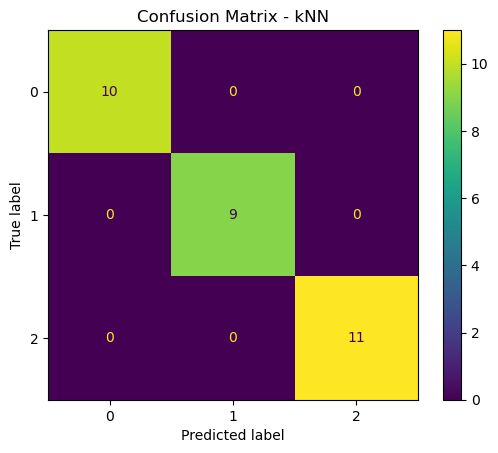

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

Confusion Matrix - SVM:


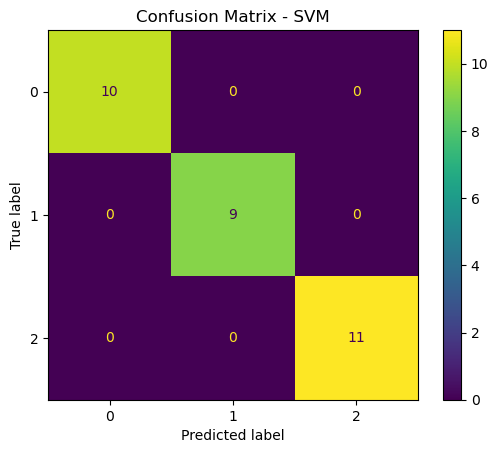

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [67]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# --- Khởi tạo mô hình ---
knn = KNeighborsClassifier(n_neighbors=5)
svm = SVC(kernel='rbf', C=1, gamma='scale')

cv = 5  # Số lượng folds

# --- Cross-validation ---
knn_cv_scores = cross_val_score(knn, X_train, y_train, cv=cv)
svm_cv_scores = cross_val_score(svm, X_train, y_train, cv=cv)

print(f"[CV] kNN Accuracy trung bình (cv={cv}): {knn_cv_scores.mean():.4f}")
print(f"[CV] SVM Accuracy trung bình (cv={cv}): {svm_cv_scores.mean():.4f}")

# --- Huấn luyện mô hình với toàn bộ tập train ---
knn.fit(X_train, y_train)
svm.fit(X_train, y_train)

# --- Dự đoán ---
y_pred_knn = knn.predict(X_test)
y_pred_svm = svm.predict(X_test)

# --- Độ chính xác trên tập test ---
acc_knn = accuracy_score(y_test, y_pred_knn)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"[Test] kNN Accuracy: {acc_knn:.4f}")
print(f"[Test] SVM Accuracy: {acc_svm:.4f}")

# --- Ma trận nhầm lẫn ---
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)

print("Confusion Matrix - kNN:")
disp_knn.plot()
plt.title("Confusion Matrix - kNN")
plt.show()
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix - SVM:")
disp_svm.plot()
plt.title("Confusion Matrix - SVM")
plt.show()
print(classification_report(y_test, y_pred_svm))

7) Cài đặt thêm 2 thuật toán: Linear Discriminant Analysis (LDA) và Random Forest (RF). So sánh kết quả giữa 4 mô hình với nhau.

In [68]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_score

In [69]:
lda = LinearDiscriminantAnalysis()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [70]:
# LDA
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)
cm_lda = confusion_matrix(y_test, y_pred_lda)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda)

# RF
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

[Test] LDA Accuracy: 1.0000
Confusion Matrix - LDA:


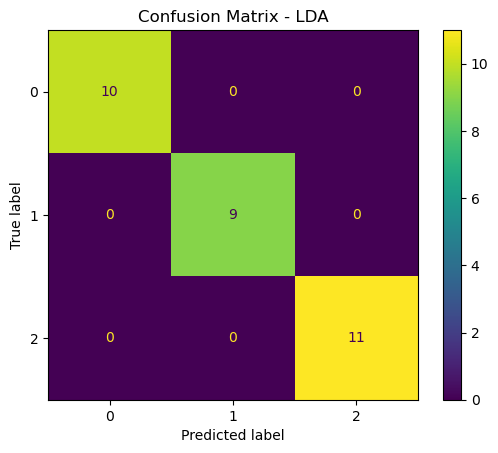

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [71]:
print(f"[Test] LDA Accuracy: {acc_lda:.4f}")
print("Confusion Matrix - LDA:")
disp_lda.plot()
plt.title("Confusion Matrix - LDA")
plt.show()
print(classification_report(y_test, y_pred_lda))

[Test] RF Accuracy: 1.0000
Confusion Matrix - Random Forest:


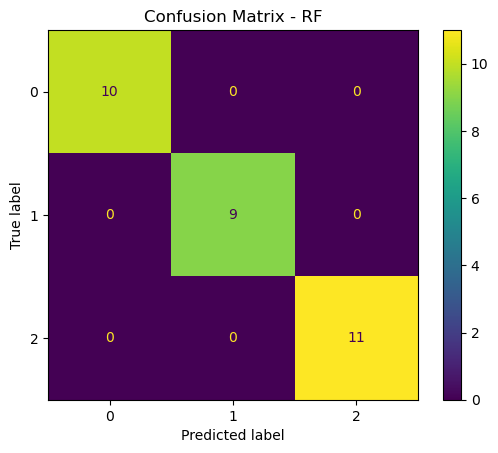

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [72]:
print(f"[Test] RF Accuracy: {acc_rf:.4f}")
print("Confusion Matrix - Random Forest:")
disp_rf.plot()
plt.title("Confusion Matrix - RF")
plt.show()
print(classification_report(y_test, y_pred_rf))

8)* Thực hiện lại các bước từ 1 tới 7 khoảng 5 lần, ứng với mỗi lần thực hiện ghi lại giá trị Accuracy và thay đổi giá trị seed. Sau đó tính và ghi ra kết quả Accuracy trung bình của 5 lần thực hiện.

In [73]:
import numpy as np

# Danh sách để lưu Accuracy
knn_accuracies = []
svm_accuracies = []
lda_accuracies = []
rf_accuracies = []

# Thực hiện 5 lần với các seed khác nhau
for seed in [42, 7, 123, 2023, 99]:
    # Bước 1-2: Chia dữ liệu (giữ nguyên X, y từ preprocessing trước đó)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Bước 3: Tạo mô hình
    knn = KNeighborsClassifier(n_neighbors=3)
    svm = SVC(kernel='linear')
    lda = LinearDiscriminantAnalysis()
    rf = RandomForestClassifier(n_estimators=100, random_state=seed)

    # Bước 4: Huấn luyện mô hình
    knn.fit(X_train, y_train)
    svm.fit(X_train, y_train)
    lda.fit(X_train, y_train)
    rf.fit(X_train, y_train)

    # Bước 5: Dự đoán
    y_pred_knn = knn.predict(X_test)
    y_pred_svm = svm.predict(X_test)
    y_pred_lda = lda.predict(X_test)
    y_pred_rf = rf.predict(X_test)

    # Bước 6: Accuracy
    acc_knn = accuracy_score(y_test, y_pred_knn)
    acc_svm = accuracy_score(y_test, y_pred_svm)
    acc_lda = accuracy_score(y_test, y_pred_lda)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    # Lưu lại kết quả
    knn_accuracies.append(acc_knn)
    svm_accuracies.append(acc_svm)
    lda_accuracies.append(acc_lda)
    rf_accuracies.append(acc_rf)

    # In kết quả từng lần
    print(f"Seed {seed} - kNN Accuracy: {acc_knn:.4f} | SVM Accuracy: {acc_svm:.4f} | LDA Accuracy: {acc_lda:.4f} | RF Accuracy: {acc_rf:.4f}")

# Bước 7: Tính độ chính xác trung bình
avg_knn = np.mean(knn_accuracies)
avg_svm = np.mean(svm_accuracies)
avg_lda = np.mean(lda_accuracies)
avg_rf = np.mean(rf_accuracies)

print("\n==============================")
print(f"Trung bình Accuracy kNN: {avg_knn:.4f}")
print(f"Trung bình Accuracy SVM: {avg_svm:.4f}")
print(f"Trung bình Accuracy LDA: {avg_lda:.4f}")
print(f"Trung bình Accuracy RF: {avg_rf:.4f}")


Seed 42 - kNN Accuracy: 1.0000 | SVM Accuracy: 1.0000 | LDA Accuracy: 1.0000 | RF Accuracy: 1.0000
Seed 7 - kNN Accuracy: 0.9000 | SVM Accuracy: 0.9667 | LDA Accuracy: 0.9667 | RF Accuracy: 0.8667
Seed 123 - kNN Accuracy: 0.9667 | SVM Accuracy: 0.9667 | LDA Accuracy: 0.9667 | RF Accuracy: 0.9333
Seed 2023 - kNN Accuracy: 1.0000 | SVM Accuracy: 1.0000 | LDA Accuracy: 1.0000 | RF Accuracy: 1.0000
Seed 99 - kNN Accuracy: 0.9333 | SVM Accuracy: 0.9667 | LDA Accuracy: 0.9667 | RF Accuracy: 0.9333

Trung bình Accuracy kNN: 0.9600
Trung bình Accuracy SVM: 0.9800
Trung bình Accuracy LDA: 0.9800
Trung bình Accuracy RF: 0.9467
